##### AI TECH - Akademia Innowacyjnych Zastosowań Technologii Cyfrowych. Programu Operacyjnego Polska Cyfrowa na lata 2014-2020
<hr>

<br>
<br>
<br>
<br>
<br>
<br>
<br>
<center>
    <h1 style = "font-size:48px; font-weight:normal"><b>AI</b>-TECH</h1>
    <br>
<br>
<br>
<br>
    <h1 style = "font-size:24px; font-weight:normal">Przykład 1 DO LABORATORIUM 5</h1>
    <h1 style = "font-size:24px">z UCZENIA MASZYNOWEGO</h1>
    <h1 style = "font-size:24px">Sztuczne sieci neuronowe</h1>
    <h1 style = "font-size:24px">Tomasz Neumann</h1>
    <h3 style = "font-size:21px">Klasyfikacja wieloklasowa, wieloetykietowa i wielowyjściowa w Scikit-Learn</h3>
</center>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
    </body>
    </html>

![stopka.svg](stopka.svg)

<center>
Projekt współfinansowany ze środków Unii Europejskiej w ramach Europejskiego Funduszu Rozwoju Regionalnego 
Program Operacyjny Polska Cyfrowa na lata 2014-2020,
Oś Priorytetowa nr 3 "Cyfrowe kompetencje społeczeństwa" Działanie  nr 3.2 "Innowacyjne rozwiązania na rzecz aktywizacji cyfrowej" 
Tytuł projektu:  „Akademia Innowacyjnych Zastosowań Technologii Cyfrowych (AI Tech)”
    </center>

<hr>

# 5. Przykład 1

Klasyfikatory wieloklasowe (wielomianowe) służą do rozróżniania większej liczby klas. Niektóre algorytmy (takie jak klasyfikatory SGD, klasyfikatory losowego lasu lub naiwne klasyfikatory bayesowskie) są w stanie natywnie zajmować się wieloma klasami naraz. W przypadku wektorów nośnych czy klasyfikatorów regresji logistycznej mają charakter typowo binarny. Istnieje jednak wiele strategii, dzięki którym możemy przeprowadzać klasyfikację wieloklasową przy użyciu wielu klasyfikatorów binarnych.

Jednym ze sposobów stworzenia systemu klasyfikującego 10 klas obrazów cyfr (od 0 do 9) polega na wyuczeniu 10 klasyfikatorów binarnych, po jednym na każdą cyfrę. Następnie na etapie klasyfikacji obrazu uzyskujemy wynik z każdego klasyfikatora dla danej cyfry i wybieramy klasę, która uzyskała najwyższy wynik. Jest to tzw. strategia jeden przeciw reszcie (<i>one-versus-rest — OvR</i> lub  <i>one-versus-all — OvA</i>). Jeszcze innym rozwiązaniem jest wyuczenie klasyfikatora binarnego dla każdej pary cyfr: jeden rozpoznaje zera i jedynki, drugi — zera i dwójki, jeszcze inny — jedynki i dwójki itd. Jest to strategia jeden przeciw jednemu (<i>one-versus-one — OvO</i>). Jeśli masz do czynienia z $N$ klasami, musisz wytrenować $N\times(N–1)/2$ klasyfikatorów. W przypadku zestawu danych MNIST oznacza to wyuczenie
45 klasyfikatorów binarnych.

Zaletą strategii <i>OvO</i> jest fakt, że każdy klasyfikator musi zostać wytrenowany jedynie wobec części zbioru uczącego składającego się z obydwu porównywanych klas. Pewne algorytmy nie skalują się zbyt dobrze do rozmiarów zbioru uczącego np. maszyna wektórów nośnych. W takim przypadku preferowane jest stosowanie strategii OvO, ponieważ uczenie wielu klasyfikatorów wobec niewielkich zbiorów danych przebiega szybciej niż trenowanie kilku klasyfikatorów wobec dużych zbiorów przykładów. Jednakże w przypadku większości klasyfikatorów binarnych zalecane jest korzystanie ze strategii <i>OvR</i>.

Moduł Scikit-Learn pozwala zastosować strategię <i>OvO</i> lub <i>OvR</i>, poprzez wykorzystanie klas <i>OneVsOneClassifier</i> lub <i>OneVsRestClassifier</i>. Wystarczy stworzyć ich wystąpienie i przekazać konstruktorowi klasyfikator (nie musi być on nawet binarny). Poniższy kod przykładu stworzy klasyfikator wieloklasowy (na podstawie klasyfikatora <i>SVC</i>) przy użyciu strategii <i>OvR</i>.

In [1]:
#import bibliotek i danych
import keras
import tensorflow as tf
import numpy as np

(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data(path='mnist.npz')
y_train = y_train.astype(np.uint8)
y_test = y_test.astype(np.uint8)
X_train = X_train.reshape(X_train.shape[0],X_train.shape[1]*X_train.shape[2])
X_test = X_test.reshape(X_test.shape[0],X_test.shape[1]*X_test.shape[2])
#zainicjowanie modelu OvR
#### UWAGA: trening trwa bardzo długo dlatego zaleca się jego wykonanie poza zajęciami i sprawdzenie rezultatów
#### W celu testów odkomentuj poniższe linijki
from sklearn.multiclass import OneVsRestClassifier
from sklearn import svm
ovr_clf = OneVsRestClassifier(svm.SVC())
ovr_clf.fit(X_train, y_train)
print(ovr_clf.predict(X_train))

[5 0 4 ... 5 6 8]


Podobnie można postąpić z klasyfikatorem SGDClassifier

In [2]:
from sklearn.linear_model import SGDClassifier
sgd_clf = SGDClassifier()
sgd_clf.fit(X_train, y_train)
print(sgd_clf.predict(X_train))

[5 0 3 ... 5 6 8]


Klasyfikatory SGD mogą bezpośrednio klasyfikować przykłady w sposób wieloklasowy, stąd też nie ma potrzeby wdrażania powyżej opisanych strategii. W takim zastosowaniu metoda <i>decision_function()</i> zwraca aktualnie po jednej wartości na jedną klasę.

In [3]:
i=1244
test0 = X_train[i].reshape(1,784)
print(test0.shape)
print(sgd_clf.predict(test0))
print(sgd_clf.decision_function(X_train)[i][:])
print('Przewidywana etykieta: ', sgd_clf.predict(X_train[i].reshape(1,784))[0])
print('Prawdziwa etykieta: ', y_train[i])

(1, 784)
[9]
[-25680.12792537 -34809.53067135  -9061.25559391 -14594.8093721
  -4784.98265286 -13833.47607736 -17879.59383141 -10787.88406468
   -181.27072667   1090.17752807]
Przewidywana etykieta:  9
Prawdziwa etykieta:  3


Jak jednak przyjrzymy się dokładniej, przy wybraniu tego obrazu do przewidywań, klasyfikator pomylił się w ocenie, wykazując największy stopień pewności wyniku dla cyfry 9, a natępnie drugą wartość dla cyfry 8, która jest także wartością nieprawidłową. Jak widać wartość przewidywań dla cyfry 3 jest dużą liczbą ujemną stąd klasyfikator nie będzie brał tej opcji do końcowych przewidywań.

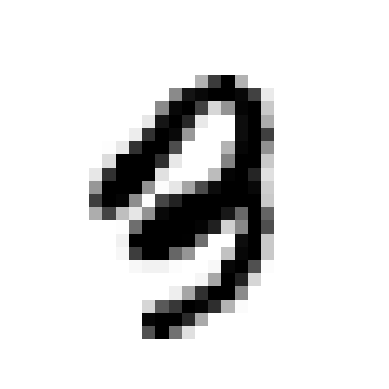

Prawdziwa etykieta:  3


In [4]:
import matplotlib as mpl
import matplotlib.pyplot as plt
some_digit_image = X_train[i].reshape(28,28)
plt.imshow(some_digit_image, cmap = "binary")
plt.axis("off")
plt.show()
print('Prawdziwa etykieta: ', y_train[i])

Był to jednak specjalnie wybrany przykład niepoprawnej klasyfikacji. W celu oceny skuteczności tego klasyfikatora można posłuzyć się sprawdzianem krzyżowym z 5-cio krotną kroswalidacją.

In [5]:
from sklearn.model_selection import cross_val_score
cross_val_score(sgd_clf, X_train, y_train, cv=5, scoring="accuracy")

KeyboardInterrupt: 

Jak widać, wobec wszystkich podzbiorów testowych uzyskuję się wynik $87\%$, co porównując to wyniku losowego klasyfikatora ($10\%$) wypada dobrze. Aby uzyskać lepszy wynik można wykorzystać przeskalowanie danych za pomocą klasy <i>StandardScaler</i>

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.astype(np.float64))
cross_val_score(sgd_clf, X_train_scaled, y_train, cv=5, scoring="accuracy")

c:\users\tomas\ella\lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:577: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  ConvergenceWarning)


array([0.90316667, 0.89566667, 0.90316667, 0.89391667, 0.89758333])

uzyskując o około $3\%$ lepszy wynik niż wcześniej bez skalowania.

Dalszą analizę wyników można dokonywać za pomocą macierzy pomyłek. Należy wyliczyć prognozy za pomocą funkcji <i>cross_val_predict()</i>, a następnie wywołać funkcję <i>confusion_matrix()</i> (rzędy reprezentują rzeczywiste klasy, kolumny zaś - przewidywane klasy)

In [43]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix
y_train_pred = cross_val_predict(sgd_clf, X_train_scaled, y_train, cv=5)
conf_mx = confusion_matrix(y_train, y_train_pred)
print(conf_mx)

[[5568    0   16    7    9   41   35    6  240    1]
 [   0 6409   42   25    3   41    4    7  203    8]
 [  26   26 5242   86   66   26   62   38  376   10]
 [  24   18  112 5234    0  195   24   40  418   66]
 [  11   14   39   13 5215   10   32   20  339  149]
 [  25   18   27  161   53 4454   78   15  530   60]
 [  28   17   45    3   41   88 5545    8  143    0]
 [  18   12   53   26   49   13    4 5697  196  197]
 [  15   60   43   90    3  121   28    8 5448   35]
 [  21   19   32   61  124   38    1  179  388 5086]]


jak i stworzyć reprezentację graficzną tych liczb.

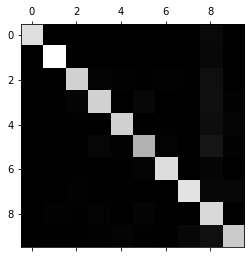

In [44]:
plt.matshow(conf_mx, cmap=plt.cm.gray)
plt.show()

Wartości w macierzy pomyłek prezentują się całkiem nieźle, gdyż większość obrazów znajduje się na głównej przekątnej, co oznacza, że zostały prawidłowo sklasyfikowane. Piątki wyglądają nieco ciemniej od pozostałych cyfr, co może oznaczać, że w zbiorze danych znajduje się mniej obrazów piątek lub że klasyfikator nie sprawuje się tak dobrze wobec piątek, jak w przypadku pozostałych cyfr. W rzeczywistości można zweryfikować obydwa stwierdzenia, jeżeli wyrysuje się diagram błędów.

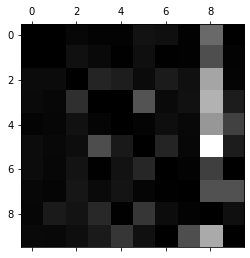

In [45]:
#podzielenie każdej wartości z macierzy pomyłek przez liczbę obrazów
row_sums = conf_mx.sum(axis=1, keepdims=True)
norm_conf_mx = conf_mx / row_sums
#Wypełnienie głównej przekątnej zerami, aby pozostały same błędy
np.fill_diagonal(norm_conf_mx, 0)
plt.matshow(norm_conf_mx, cmap=plt.cm.gray)
plt.show()

Kolumna reprezentująca klasę 8 jest dość jasna, co oznacza, że wiele obrazów zostało nieprawidłowo sklasyfikowanych jako ta właśnie cyfra. Jednak rząd klasy 8 nie wygląda tak źle, co oznacza, że zasadniczo większość ósemek jest prawidłowo klasyfikowanych.
Jak widać, macierz pomyłek nie jest zbyt symetryczna. Można również dostrzec, że trójki i piątki są często mylone (w obydwie strony).
Analiza macierzy pomyłek często dostarcza wskazówek pozwalających usprawnić klasyfikator. Można byłoby popracować nad zmniejszeniem liczby fałszywych ósemek tworząc nowe cechy bądź też dokonać wstępnego przetwarzania obrazów (korzystając z modułów Scikit-Image, Pillow lub OpenCV), aby uwypuklić pewne wzorce.

<b>Klasyfikacja wieloetykietowa</b> (multilabel classification)

Powyższy kod analizował pojedyncze przykłady i przydzielał je wyłącznie do jednej klasy. W niektórych sytuacjach
może zachodzić potrzeba, aby klasyfikator wyznaczał wiele klas dla jednego wystąpienia.

W tym celu zaimplemontowane zostaną dwie docelowe etykiety dla każdego obrazu cyfry. Niech pierwsza z nich określa, czy jest to duża liczba, zaś druga niech opisuje, że liczba jest nieparzysta. Następnie zostaje utworzone wystąpienie klasyfikatora <i>KNeighborsClassifier</i>, po czym jest on uczony za pomocą tablicy zawierającej wiele docelowych elementów

In [46]:
from sklearn.neighbors import KNeighborsClassifier
y_train_large = (y_train >= 7)
y_train_odd = (y_train % 2 == 1)
y_multilabel = np.c_[y_train_large, y_train_odd]
knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train, y_multilabel)

KNeighborsClassifier()

oraz dokonywane są prognozy.

In [47]:
print(knn_clf.predict(X_train[0:7]))
print('Prawdziwa etykieta: ', y_train[0:7])

[[False  True]
 [False False]
 [False False]
 [False  True]
 [ True  True]
 [False False]
 [False  True]]
Prawdziwa etykieta:  [5 0 4 1 9 2 1]


Jak widać prognoza do obrazu pierwszego, reprezentującego 5-tkę zgadza się - nie jest to wielka cyfra (większa od 6) oraz jest to cyfra nieparzysta. Aby jednak lepiej ocenić wydajność klasyfikatora można obliczyć F-Score dla poszczególnych etykiet (zakładając, że każda ma taką samą wagę), a następnie wyliczeniu średniej.

In [48]:
from sklearn.metrics import *
y_train_knn_pred = cross_val_predict(knn_clf, X_train, y_multilabel, cv=5)
print(f1_score(y_multilabel, y_train_knn_pred, average="weighted"))

0.9788245246428662


W celu nadania każdej etykiecie wagi równej jej współczynnikowi wsparcia (support) np. liczba próbek zawierających etykietę docelową, można użyć wyrażenia <i>average="weighted"</i>.

<b>Klasyfikacja wielowyjściowa</b>
Ostatnim rodzajem zadania klasyfikacyjnego jest klasyfikacja wielowyjściowa (<i>multioutput classification</i>). Jest to po prostu uogólnienie klasyfikacji wieloetykietowej, gdzie każda etykieta może być wieloklasowa tj. może mieć ponad dwie możliwe wartości. Można to przedstawić na systemie, który będzie usuwał szum z obrazów cyfr.
Danymi wejściowymi będą poprzednie obrazy, które będą zmodyfikowane poprzez dodanie dodatkowego szumu zaś na wyjściu należy spodziewać się obrazu cyfr w postaci zawierającej poziomy szarości poszczególnych pikseli (na jeden piksel przypada jedna etykieta, a każda z etykiet może mieć różne wartości z zakresu poziomów szarości od 0 do 255)

In [49]:
noise = np.random.randint(0, 100, (len(X_train), 784))
X_train_mod = X_train + noise
noise = np.random.randint(0, 100, (len(X_test), 784))
X_test_mod = X_test + noise
y_train_mod = X_train
y_test_mod = X_test

oraz wyświetlimy tak zmodyfikowany obraz.

Zaszumiony obraz


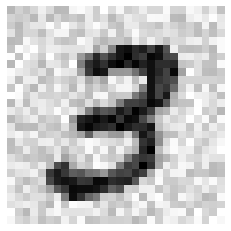

Prawdziwa etykieta:  3


In [50]:
print('Zaszumiony obraz')
plt.imshow(X_train_mod[7].reshape(28,28), cmap = "binary")
plt.axis("off")
plt.show()
print('Prawdziwa etykieta: ', y_train[7])

Następnie wytrenowujemy klasyfikator na tak zmodyfikowanych danych wejściowych i analizujemy wyniki predykcji

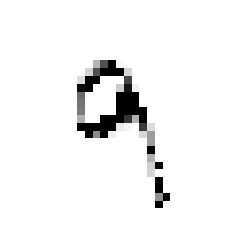

Prawdziwa etykieta:  3


In [15]:
knn_clf.fit(X_train_mod, y_train_mod)
clean_digit = knn_clf.predict([X_test_mod[7]])
plt.imshow(clean_digit.reshape(28,28), cmap = "binary")
plt.axis("off")
plt.show()
print('Prawdziwa etykieta: ', y_train[7])

które nie zawsze muszą odzwierciedlać pierwotny stan naszej cyfry wobec wprowadzonego szumu.

# Zadania do wykonania (Do wyboru)

<p><b>Zadanie 1</b></p>
Wykonaj i oceń wynik klasyfikacji wieloklasowej cyfr ze zbioru MNIST wyłącznie dla cyfr znajdujących się w Twoim numerze albumu.
<p><b>Zadanie 2</b></p>
Dla przykładu klasyfikacji wieloetykietowej przeprowadź eksperymenty, aby klasyfikować liczby pierwsze i podzielne przez 3.
<p><b>Zadanie 3</b></p>
Dla przykładu klasyfikacji wielowyjściowej wykonaj dwa eksperymenty dla różnych przedziałów zaszumienia oraz przeprowadź testy dla cyfry będącej odpowiednikiem ostatniej cyfry z Twojego numeru albumu.  

## Rozwiązanie zadań 1-3

Numer albumu: `193257`.

Czyli cyfry brane pod uwagę do zadania 1 to: `1, 2, 3, 5, 7, 9`

Do zadania 3 testowana cyfra to `7`.

In [ ]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import SGDClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    recall_score,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

np.set_printoptions(linewidth=160)

RANDOM_STATE = 42
album_number = "193257"
album_digits = sorted({int(digit) for digit in album_number})
last_digit = int(album_number[-1])

mnist_path = Path.home() / ".keras" / "datasets" / "mnist.npz"
with np.load(mnist_path) as data:
    X_train_img = data["x_train"]
    y_train = data["y_train"].astype(np.uint8)
    X_test_img = data["x_test"]
    y_test = data["y_test"].astype(np.uint8)

X_train = X_train_img.reshape(len(X_train_img), -1).astype(np.float32)
X_test = X_test_img.reshape(len(X_test_img), -1).astype(np.float32)

print(f"Cyfry użyte w zadaniu 1: {album_digits}")
print(f"Ostatnia cyfra numeru albumu: {last_digit}")
print(f"Zbiór treningowy: {X_train.shape}, zbiór testowy: {X_test.shape}")


Numer albumu: 193257
Cyfry użyte w zadaniu 1: [1, 2, 3, 5, 7, 9]
Ostatnia cyfra numeru albumu: 7
Zbiór treningowy: (60000, 784), zbiór testowy: (10000, 784)


### Zadanie 1

Klasyfikacja wieloklasowa -> tylko dla cyfr występujących windeksie, czyli dla klas `1, 2, 3, 5, 7, 9`. Używane jest `SGDClassifier` po standaryzacji danych, bo w przykładzie wcześniej też był używany klasyfikator SGD.


In [2]:
train_mask = np.isin(y_train, album_digits)
test_mask = np.isin(y_test, album_digits)

X_train_album = X_train[train_mask]
y_train_album = y_train[train_mask]
X_test_album = X_test[test_mask]
y_test_album = y_test[test_mask]

sgd_album_clf = make_pipeline(
    StandardScaler(),
    SGDClassifier(random_state=RANDOM_STATE, max_iter=1000, tol=1e-3),
)
sgd_album_clf.fit(X_train_album, y_train_album)
y_pred_album = sgd_album_clf.predict(X_test_album)

train_counts = {int(digit): int((y_train_album == digit).sum()) for digit in album_digits}
test_counts = {int(digit): int((y_test_album == digit).sum()) for digit in album_digits}
conf_mx_album = confusion_matrix(y_test_album, y_pred_album, labels=album_digits)

print(f"Liczba próbek treningowych dla wybranych cyfr: {train_counts}")
print(f"Liczba próbek testowych dla wybranych cyfr: {test_counts}")
print(f"Dokładność na zbiorze testowym: {accuracy_score(y_test_album, y_pred_album):.4f}")
print(f"Macierz pomyłek (wiersze=prawdziwe, kolumny=predykcje; etykiety={album_digits}):")
print(conf_mx_album)
print()
print("Raport klasyfikacji:")
print(classification_report(y_test_album, y_pred_album, labels=album_digits, digits=4, zero_division=0))


Liczba próbek treningowych dla wybranych cyfr: {1: 6742, 2: 5958, 3: 6131, 5: 5421, 7: 6265, 9: 5949}
Liczba próbek testowych dla wybranych cyfr: {1: 1135, 2: 1032, 3: 1010, 5: 892, 7: 1028, 9: 1009}
Dokładność na zbiorze testowym: 0.9135
Macierz pomyłek (wiersze=prawdziwe, kolumny=predykcje; etykiety=[1, 2, 3, 5, 7, 9]):
[[1093    2   38    2    0    0]
 [   4  924   86    9    6    3]
 [   0   11  957   25    9    8]
 [   6    8   81  778    6   13]
 [   0   13   65    0  926   24]
 [   6    4   79    4   16  900]]

Raport klasyfikacji:
              precision    recall  f1-score   support

           1     0.9856    0.9630    0.9742      1135
           2     0.9605    0.8953    0.9268      1032
           3     0.7328    0.9475    0.8264      1010
           5     0.9511    0.8722    0.9099       892
           7     0.9616    0.9008    0.9302      1028
           9     0.9494    0.8920    0.9198      1009

    accuracy                         0.9135      6106
   macro avg     0.92

**Wnioski - zadanie 1**

Po odfiltrowaniu MNIST do cyfr z mojego numeru albumu, czyli `1, 2, 3, 5, 7, 9`, klasyfikator SGD po standaryzacji uzyskał dokładność `0.9135` na `6106` próbkach testowych. Najpewniej rozpoznawana była cyfra `1` (`precision=0.9856`, `recall=0.9630`). Największy problem widać przy cyfrze `3`: ma wysoki `recall=0.9475`, ale niższe `precision=0.7328`, bo model dość często przypisywał do klasy `3` także inne cyfry, np. `86` dwójek, `81` piątek, `79` dziewiątek i `65` siódemek. Ogólnie wynik jest dobry, ale macierz pomyłek pokazuje, że model za często wybiera klasę `3`.


### Zadanie 2

Tu są tworzone dwie etykiety naraz: czy cyfra jest pierwsza (`2, 3, 5, 7`) oraz czy jest podzielna przez `3` (`0, 3, 6, 9`). Do eksperymentu używam KNN, tak jak w przykładzie klasyfikacji wieloetykietowej.


In [3]:
prime_digits = [2, 3, 5, 7]
divisible_by_3_digits = [0, 3, 6, 9]

y_train_multilabel = np.c_[
    np.isin(y_train, prime_digits),
    np.isin(y_train, divisible_by_3_digits),
]
y_test_multilabel = np.c_[
    np.isin(y_test, prime_digits),
    np.isin(y_test, divisible_by_3_digits),
]

rng_task2 = np.random.default_rng(RANDOM_STATE)
task2_train_indices = []
for digit in range(10):
    digit_indices = np.flatnonzero(y_train == digit)
    task2_train_indices.extend(rng_task2.choice(digit_indices, size=1200, replace=False))
task2_train_indices = np.array(task2_train_indices)
rng_task2.shuffle(task2_train_indices)

knn_multilabel_clf = KNeighborsClassifier(
    n_neighbors=3,
    weights="distance",
    algorithm="brute",
    n_jobs=-1,
)
knn_multilabel_clf.fit(X_train[task2_train_indices], y_train_multilabel[task2_train_indices])
y_pred_multilabel = knn_multilabel_clf.predict(X_test)

label_names = ["liczba pierwsza", "podzielna przez 3"]
label_accuracy = (y_test_multilabel == y_pred_multilabel).mean(axis=0)
precision_values = precision_score(y_test_multilabel, y_pred_multilabel, average=None, zero_division=0)
recall_values = recall_score(y_test_multilabel, y_pred_multilabel, average=None, zero_division=0)
f1_values = f1_score(y_test_multilabel, y_pred_multilabel, average=None, zero_division=0)

print(f"Użyty podzbiór treningowy: {len(task2_train_indices)} próbek (po 1200 z każdej cyfry)")
print(f"Zbiór testowy: {len(X_test)} próbek")
print(f"Exact match accuracy: {accuracy_score(y_test_multilabel, y_pred_multilabel):.4f}")
for index, label_name in enumerate(label_names):
    print(
        f"{label_name}: accuracy={label_accuracy[index]:.4f}, "
        f"precision={precision_values[index]:.4f}, "
        f"recall={recall_values[index]:.4f}, "
        f"F1={f1_values[index]:.4f}"
    )
print(f"F1 weighted: {f1_score(y_test_multilabel, y_pred_multilabel, average='weighted', zero_division=0):.4f}")
print()
print("Macierz pomyłek - liczba pierwsza:")
print(confusion_matrix(y_test_multilabel[:, 0], y_pred_multilabel[:, 0]))
print("Macierz pomyłek - podzielna przez 3:")
print(confusion_matrix(y_test_multilabel[:, 1], y_pred_multilabel[:, 1]))


Użyty podzbiór treningowy: 12000 próbek (po 1200 z każdej cyfry)
Zbiór testowy: 10000 próbek
Exact match accuracy: 0.9617
liczba pierwsza: accuracy=0.9777, precision=0.9780, recall=0.9654, F1=0.9717
podzielna przez 3: accuracy=0.9737, precision=0.9622, recall=0.9717, F1=0.9669
F1 weighted: 0.9693

Macierz pomyłek - liczba pierwsza:
[[5952   86]
 [ 137 3825]]
Macierz pomyłek - podzielna przez 3:
[[5892  151]
 [ 112 3845]]


**Wnioski - zadanie 2**

Dla klasyfikacji wieloetykietowej KNN trenowany na `12000` próbkach dał `exact match accuracy=0.9617`, więc w większości przypadków trafiał obie etykiety jednocześnie. Etykieta `liczba pierwsza` wyszła minimalnie lepiej (`F1=0.9717`) niż etykieta `podzielna przez 3` (`F1=0.9669`), ale różnica jest mała. W macierzy pomyłek dla liczb pierwszych było `86` fałszywych alarmów i `137` pominięć, a dla podzielności przez `3` odpowiednio `151` fałszywych alarmów i `112` pominięć. Wyniki są dobre, bo obie etykiety mają accuracy powyżej `0.97`.


### Zadanie 3

Dla klasyfikacji wielowyjściowej robię dwa eksperymenty odszumiania: szum z przedziału `0-50` oraz `0-150`. Testuję cyfrę `7`, bo to ostatnia cyfra numeru albumu. W tym zadaniu każdy piksel traktuję jako osobne wyjście klasyfikatora KNN.


In [4]:
rng_task3 = np.random.default_rng(RANDOM_STATE)
task3_train_indices = []
for digit in range(10):
    digit_indices = np.flatnonzero(y_train == digit)
    task3_train_indices.extend(rng_task3.choice(digit_indices, size=800, replace=False))
task3_train_indices = np.array(task3_train_indices)
rng_task3.shuffle(task3_train_indices)

X_train_clean_small = X_train[task3_train_indices].astype(np.uint8)
digit_test_indices = np.flatnonzero(y_test == last_digit)[:100]
X_test_digit_clean = X_test[digit_test_indices].astype(np.uint8)

noise_ranges = [(0, 50), (0, 150)]
denoising_results = []
example_images = []

for low, high in noise_ranges:
    local_rng = np.random.default_rng(RANDOM_STATE + high)
    train_noise = local_rng.integers(low, high + 1, size=X_train_clean_small.shape, dtype=np.uint16)
    test_noise = local_rng.integers(low, high + 1, size=X_test_digit_clean.shape, dtype=np.uint16)

    X_train_noisy = np.clip(X_train_clean_small.astype(np.uint16) + train_noise, 0, 255).astype(np.uint8)
    X_test_digit_noisy = np.clip(X_test_digit_clean.astype(np.uint16) + test_noise, 0, 255).astype(np.uint8)

    knn_denoiser = KNeighborsClassifier(
        n_neighbors=3,
        weights="distance",
        algorithm="brute",
        n_jobs=-1,
    )
    knn_denoiser.fit(X_train_noisy, X_train_clean_small)
    X_digit_denoised = knn_denoiser.predict(X_test_digit_noisy).astype(np.float32)

    clean = X_test_digit_clean.astype(np.float32)
    noisy = X_test_digit_noisy.astype(np.float32)
    denoising_results.append(
        {
            "noise_range": f"{low}-{high}",
            "noisy_mse": mean_squared_error(clean, noisy),
            "denoised_mse": mean_squared_error(clean, X_digit_denoised),
            "noisy_mae": mean_absolute_error(clean, noisy),
            "denoised_mae": mean_absolute_error(clean, X_digit_denoised),
            "first_digit_noisy_mse": mean_squared_error(clean[0], noisy[0]),
            "first_digit_denoised_mse": mean_squared_error(clean[0], X_digit_denoised[0]),
        }
    )
    example_images.append((f"{low}-{high}", clean[0], noisy[0], X_digit_denoised[0]))

print(f"Użyty podzbiór treningowy: {len(task3_train_indices)} próbek (po 800 z każdej cyfry)")
print(f"Testowana cyfra: {last_digit}, liczba testowanych obrazów: {len(digit_test_indices)}")
for result in denoising_results:
    mse_change = (1 - result["denoised_mse"] / result["noisy_mse"]) * 100
    print(
        f"Szum {result['noise_range']}: "
        f"MSE przed={result['noisy_mse']:.2f}, MSE po={result['denoised_mse']:.2f}, "
        f"MAE przed={result['noisy_mae']:.2f}, MAE po={result['denoised_mae']:.2f}, "
        f"zmiana MSE={mse_change:.2f}%"
    )
    print(
        f"Pierwsza testowana 7: MSE przed={result['first_digit_noisy_mse']:.2f}, "
        f"MSE po={result['first_digit_denoised_mse']:.2f}"
    )

fig, axes = plt.subplots(len(example_images), 3, figsize=(8, 5))
for row, (noise_label, clean_image, noisy_image, denoised_image) in enumerate(example_images):
    axes[row, 0].imshow(clean_image.reshape(28, 28), cmap="binary")
    axes[row, 0].set_title(f"Oryginał 7")
    axes[row, 1].imshow(noisy_image.reshape(28, 28), cmap="binary")
    axes[row, 1].set_title(f"Szum {noise_label}")
    axes[row, 2].imshow(denoised_image.reshape(28, 28), cmap="binary")
    axes[row, 2].set_title("Po KNN")
    for col in range(3):
        axes[row, col].axis("off")
plt.tight_layout()
plt.show()


Użyty podzbiór treningowy: 8000 próbek (po 800 z każdej cyfry)
Testowana cyfra: 7, liczba testowanych obrazów: 100
Szum 0-50: MSE przed=778.68, MSE po=1594.20, MAE przed=23.39, MAE po=11.19, zmiana MSE=-104.73%
Pierwsza testowana 7: MSE przed=804.28, MSE po=510.99
Szum 0-150: MSE przed=6827.54, MSE po=1775.59, MAE przed=69.00, MAE po=12.03, zmiana MSE=73.99%
Pierwsza testowana 7: MSE przed=6848.63, MSE po=510.99


**Wnioski - zadanie 3**

Dla cyfry `7` mocniejszy szum `0-150` został odszumiony wyraźnie lepiej: średni `MSE` spadł z `6827.54` do `1775.59`, a `MAE` z `69.00` do `12.03`. Przy słabszym szumie `0-50` wynik jest mieszany: `MAE` poprawił się z `23.39` do `11.19`, ale `MSE` pogorszył się z `778.68` do `1594.20`. Dla pierwszej testowanej siódemki odszumianie poprawiło `MSE` w obu eksperymentach (`804.28 -> 510.99` oraz `6848.63 -> 510.99`). Wyszło więc, że KNN pomaga szczególnie przy mocnym zaszumieniu, a przy lekkim szumie potrafi zmienić kształt cyfry na tyle, że średni błąd kwadratowy może wyjść gorszy.


![stopka.svg](stopka.svg)